In [1]:
# commented by AC 8/4/2020 and in discussion w/ LF 8/6/2020, recommented 3/1/2021
# reminder - julia is indexed at 1 not 0!!

#import things! only needs to be done once, then can comment this away 
import Pkg;
Pkg.add("CSV")
Pkg.add("DataFrames")
Pkg.add("ForwardDiff")
Pkg.add("SharedArrays")
Pkg.add("Optim")
Pkg.add("LinearAlgebra")
Pkg.add("StatsFuns")
Pkg.add("SpecialFunctions")
Pkg.add("Statistics")
Pkg.build("SpecialFunctions")
Pkg.add("Plots")
Pkg.add("PyPlot")
Pkg.add("Distributions")

   Updating registry at `~/.julia/registries/General`
######################################################################### 100.0%
  Resolving package versions...
  Installed Qt_jll ──── v5.15.2+3
  Installed Rmath_jll ─ v0.2.2+2
No Changes to `~/.julia/environments/v1.5/Project.toml`
Updating `~/.julia/environments/v1.5/Manifest.toml`
  [ede63266] ↑ Qt_jll v5.15.2+1 ⇒ v5.15.2+3
  [f50d1b31] ↑ Rmath_jll v0.2.2+1 ⇒ v0.2.2+2
  Resolving package versions...
No Changes to `~/.julia/environments/v1.5/Project.toml`
No Changes to `~/.julia/environments/v1.5/Manifest.toml`
  Resolving package versions...
No Changes to `~/.julia/environments/v1.5/Project.toml`
No Changes to `~/.julia/environments/v1.5/Manifest.toml`
  Resolving package versions...
No Changes to `~/.julia/environments/v1.5/Project.toml`
No Changes to `~/.julia/environments/v1.5/Manifest.toml`
  Resolving package versions...
No Changes to `~/.julia/environments/v1.5/Project.toml`
No Changes to `~/.julia/environments/v1.5/Mani

In [193]:
Pkg.add("MAT")

  Resolving package versions...
  Installed LibSSH2_jll ──────── v1.9.0+3
  Installed LibCURL_jll ──────── v7.70.0+2
  Installed nghttp2_jll ──────── v1.40.0+2
  Installed CodecZlib ────────── v0.7.0
  Installed HDF5_jll ─────────── v1.12.0+1
  Installed Blosc_jll ────────── v1.14.3+1
  Installed BufferedStreams ──── v1.0.0
  Installed MAT ──────────────── v0.10.1
  Installed Blosc ────────────── v0.7.0
  Installed Lz4_jll ──────────── v1.9.2+2
  Installed HDF5 ─────────────── v0.15.5
  Installed TranscodingStreams ─ v0.9.5
Updating `~/.julia/environments/v1.5/Project.toml`
  [23992714] + MAT v0.10.1
Updating `~/.julia/environments/v1.5/Manifest.toml`
  [a74b3585] + Blosc v0.7.0
  [0b7ba130] + Blosc_jll v1.14.3+1
  [e1450e63] + BufferedStreams v1.0.0
  [944b1d66] + CodecZlib v0.7.0
  [f67ccb44] + HDF5 v0.15.5
  [0234f1f7] + HDF5_jll v1.12.0+1
  [deac9b47] + LibCURL_jll v7.70.0+2
  [29816b5a] + LibSSH2_jll v1.9.0+3
  [5ced341a] + Lz4_jll v1.9.2+2
  [23992714] + MAT v0.10.1
  [3bb67fe8] 

### 1. Load files

In [2]:
# this loads all the files
# & sets up the various behavioral variables in the way ND's code expects
# & has leftover unused code to concatenate multiple files into one dataframe (from earlier/old analyses)


using CSV #using lets you directly use outside pkgs without having to call pkg.fxn() instead just fxn(), unlike import
using DataFrames

saveCSV = 0 #a flag for whether you want to save output later or not, 0 is no, 1 is yes to saving csv output

rat = "peanut"

files = [string(rat,"_clean_contingencies_only_parsed_depletion_data.csv")] 

data = [] #nondecaying "data," decaying "data2"

for i = 1:length(files)
    df = CSV.read(files[i], DataFrame) #ac had to add "DataFrame" to this, maybe b/c changed kernels, seems to work ok now with updated syntax

    # recode some variables
    df.rewscaled = 2 * df.reward .- 1 #get reward to -1 or 1 no or yes instead of 0 to 1
    df.stemchoice = [df[i,:stem][1] - 'A' + 1 for i in 1:nrow(df)] #get stem choice to be represented as 1 2 3 instead of A B C
    df.leafchoice = 1 .+ mod.(df.leaf.+1,2)  #leaf choice keep represented as 1-6 (12 are on stem 1, 34 are on stem 2, and 56 on stem 3)

    # break up / index sessions by date (ie model continuous learning from one 
    # session to the next within each date)
    dates = unique(df.date)
    df.daynum = [minimum(findall(df[i,:date] .== dates)) for i in 1:nrow(df)] #maybe worth trying breaking up on date, session, and contingnecy - my guess is session will be most predictive. AC tried this, we can look at results together sometime. 
    df.sub = df.daynum # different parameters per day (code calls this "sub" for "subject") #variable adapted from prior code where we were using multiple rats instead of one rat on multiple days, now just looks like sloppy variable naming
    
    if (i == 1)
        data = df
    else
        data =[data;df]
    end
end  

#=
files = [string(rat,"_clean_contingencies_only_parsed_depletion_data.csv")] #repeat for other version of task

data2 = []

for i = 1:length(files)
    df = CSV.read(files[i], DataFrame) #ac had to add "DataFrame" to this, maybe b/c changed kernels, as in above

    # recode some variables
    df.rewscaled = 2 * df.reward .- 1
    df.stemchoice = [df[i,:stem][1] - 'A' + 1 for i in 1:nrow(df)]
    df.leafchoice = 1 .+ mod.(df.leaf.+1,2)

    # break up / index sessions by date (ie model continuous learning from one 
    # session to the next within each date)
    dates = unique(df.date)
    df.daynum = [minimum(findall(df[i,:date] .== dates)) for i in 1:nrow(df)]
    df.sub = df.daynum # different parameters per day (code calls this "sub" for "subject")
    
    if (i == 1)
        data2 = df
    else
        data2 =[data;df]
    end
end
=#



#now have two dataframes with rescaled variables appended horizontally


In [3]:
data[1:2,:]

,Column1,leaf,stem,reward,contingency,date,session,trial,rewscaled
,Int64,Int64,String,Int64,Int64,Int64,Int64,Int64,Int64
1,0,4,B,1,805020802050,20201109,1,0,1
2,1,3,B,0,805020642050,20201109,1,1,-1


In [4]:
# set up the EM fitting code
# this allows parameters to vary by day

parallel = true    # Run on multiple CPUs.
full = false       # Maintain full (vs diagonal) covariance matrix (of parameters across days)  
emtol = 1e-3

using Distributed
if (parallel)
	addprocs()
end

@everywhere using DataFrames
@everywhere using SharedArrays
@everywhere using ForwardDiff
@everywhere using Optim
@everywhere using LinearAlgebra       # for tr, diagonal
@everywhere using StatsFuns           # logsumexp
@everywhere using SpecialFunctions    # for erf
@everywhere using Statistics          # for mean

### 2. Define model and likelihood

In [5]:
# load the EM code (these are separate .jl files)
@everywhere directory = "/Users/shijiegu/Documents/Second-Year/w_Alison/" #"/home/daw/winhome/Dropbox (Princeton)/expts/julia em/git/em/"
@everywhere include("$directory/em.jl");
@everywhere include("$directory/common.jl");

In [6]:
# this is the likelihood function for the actual model

@everywhere function qlik(params,data)
    # these are the free parameters
    betago = params[1]   # beta for switch to alternative stem 
    betastay = params[2] # beta for current stem
    betaleaf = params[3] # beta for leaf choice on switch
    stay = params[4]     # bias toward staying
    lr = 0.5 + 0.5 * erf(params[5] / sqrt(2)) # learning rate (squashed to 0-1 using standard normal CDF)

    # rename the variables for easy acccess
    
    r = data[:,:rewscaled]
	c1 = data[:,:stemchoice]
    c2 = data[:,:leafchoice]

    # initialize 
    
    lik = 0
	
    Q = zeros(typeof(betago),3,2,length(c1))
    prevs = 0 #stem?
    prevl = 0 #leaf?
    
    # loop over all trials (e.g. for one animal)
    
	for i = 1:length(c1)

        # restart learning each day
        if ((i>1) && (data[i,:daynum] != data[i-1,:daynum]))
            Q_ = zeros(typeof(betago),3,2)
            prevs = 0
            prevl = 0
        else
            Q_=Q[:,:,max(i-1,1)]
        end
        
        # this is the (scaled) value of switching to each alternative stem
        # mean averages over both leaves
        Qeff = betago * mean(Q_,dims=2)

        # this is the (scaled) value of staying with the current stem
        # uses only the value of the next leaf because the implicit assumption that the rat knows to alternate between leaves
        # plus the bias toward staying
        if (prevs > 0)
            Qeff[prevs] = betastay * Q_[prevs,3-prevl] + stay
        end

        # log likelihood of stem choice (log of logistic)
		lik += Qeff[c1[i]] - logsumexp(Qeff)
        if (prevs != c1[i])
            # log likelihood of leaf choice on switches only
            # (meaningless for stay)
            lik += betaleaf * Q_[c1[i],c2[i]] - logsumexp(betaleaf * Q_[c1[i],:]);
        end

        # learn about the chosen leaf
        Q[c1[i],c2[i],i] = (1-lr) * Q_[c1[i],c2[i]] + lr * r[i]

        prevs = c1[i]
        prevl = c2[i]
        
	end

	return -lik
end


# these are four nested models that omit one (or all) of the decision variables
# by setting the corresponding scale to zero
# so as to test whether choices are significantly affected by each of them

@everywhere qliknogo(x,d) = qlik([0;x],d) #params, data are inputs to fxn

@everywhere qliknostay(x,d) = qlik([x[1];0;x[2:4]],d)

@everywhere qliknoleaf(x,d) = qlik([x[1:2];0;x[3:4];0],d)

@everywhere qliknull(x,d) = qlik([0;0;0;x[1];0],d)

In [7]:
length(data[:,"stemchoice"])

19004

In [8]:
# this runs the model (to compute per trial Q values) but not caluculating the likelihood
# have to duplicate from qlik because of the fit function for qlik

@everywhere function qsim(params,data)
    # these are the free parameters
    betago = params[1]   # beta for switch to alternative stem 
    betastay = params[2] # beta for current stem
    betaleaf = params[3] # beta for leaf choice on switch
    stay = params[4]     # bias toward staying
    lr = 0.5 + 0.5 * erf(params[5] / sqrt(2)) # learning rate (squashed to 0-1 using standard nomrmal CDF)

    # rename the variables for easy acccess
    
    r = data[:,:rewscaled]
	c1 = data[:,:stemchoice]
    c2 = data[:,:leafchoice]

    # initialize 
    
    Q = zeros(typeof(betago),3,2,length(c1)+1)
    prevs = 0
    prevl = 0
    
    # loop over all trials (e.g. for one animal)
    
	for i = 1:length(c1)
        # restart learning each day
        if ((i>1) && (data[i,:daynum] != data[i-1,:daynum]))
            Q[:,:,i] = zeros(typeof(betago),3,2)

            prevs = 0
            prevl = 0
        end
        
        # this is the (scaled) value of switching to each alternative stem
        # mean averages over both leaves
        Qeff = betago * mean(Q[:,:,i],dims=2)

        # this is the (scaled) value of staying with the current stem
        # uses only the value of the next leaf
        # plus the bias toward staying
        if (prevs > 0)
            Qeff[prevs] = betastay * Q[prevs,3-prevl,i] + stay
        end

    
        # learn about the chosen leaf
        Q[:,:,i+1] = Q[:,:,i]
        Q[c1[i],c2[i],i+1] =  (1-lr) * Q[c1[i],c2[i],i] + lr * r[i]

        prevs = c1[i]
        prevl = c2[i]
	end

	return Q[:,:,2:length(c1)+1]
end

### 3. Fit parameters and Run model

In [30]:
length(session_starts)

67

In [31]:
# estimate parameters
# original task
trial_to_try=5734:5834
data_short=data[trial_to_try,:]

session_ends=findall(x->x!=0,diff(data[:,"session"]));
session_starts=[1;session_ends.+1]; #all sessions
session_starts=session_starts[session_starts.>=trial_to_try[1].&session_starts.<trial_to_try[2]];

subs = unique(data_short[:,:sub]); #in this case subs is just differentiating days rather than rats/subjects, poor variable naming
NS = length(subs); #number of subjects/days
X = ones(NS); # (group level design matrix); #x group level design matrix... matrix across all days of this task)

# fit the full model
params_session=zeros(length(session_starts),5);
lik_session=zeros(length(session_starts),1);
initbetas = [0. 0 0 0 0];
initsigma = [5., 5, 5, 5, 1];

for session_index=1:length(session_starts)
    start_ind=session_starts[session_index]
    if session_index<length(session_starts)
        ed_ind=session_starts[session_index+1]-1
    else
        ed_ind=trial_to_try[2]
    end
    data_session=data[start_ind:ed_ind,:];
    (b,s,x,l,h) = em(data_session,subs,X,initbetas,initsigma,qlik; emtol=1e-3, parallel=parallel, full=full, maxiter = 1000);
    initbetas = b;
    initsigma = s;
    params_session[session_index,:]=b
    lik_session[session_index]=qlik(b,data_session)
end
lr=map(x-> 0.5 + 0.5 * erf(x/ sqrt(2)), params_session[:,5])


iter: 1001
betas: [0.0 0.0 0.0 1.84 0.0]
sigma: [5.0, 5.0, 5.0, 0.0, 1.0]
free energy: 0.0
change: [NaN, NaN, NaN, 0.0, NaN, 0.0, 0.0, 0.0, 0.0, 0.0]
max: NaN


67-element Array{Float64,1}:
 0.5
 0.5
 0.5
 0.5
 0.5
 0.5
 0.5
 0.5
 0.5
 0.5
 0.5
 0.5
 0.5
 ⋮
 0.5
 0.5
 0.5
 0.5
 0.5
 0.5
 0.5
 0.5
 0.5
 0.5
 0.5
 0.5

In [10]:
lik_session

3×1 Array{Float64,2}:
 133.56470328821334
 140.8184568006638
 162.00286736793322

In [276]:
lr

3-element Array{Float64,1}:
 0.8285285153032171
 0.8265851663484158
 0.8300098641463445

In [277]:
params_session

3×5 Array{Float64,2}:
 -0.388854  1.75272  -1.1749    4.38218  0.948366
 -0.294541  1.84459   0.483449  4.36822  0.940756
 -0.310385  1.8746    0.543378  4.34737  0.954204

In [278]:
session_starts

3-element Array{Int64,1}:
   1
 301
 601

In [279]:
Q=Array{Any}(undef,length(session_starts))
for session_index=1:length(session_starts)
    data_session=data[session_starts[session_index]:min(session_ends[session_index],trial_to_try),:];
    Q[session_index]=qsim(params_session[session_index,:],data_session)
end

In [280]:
session_ends[5]

1500

In [281]:
using MAT
matwrite(rat*" q_learning_version1_session_depletion.mat",Dict("Q"=>Q,"lr"=>lr,"params"=>params_session,"lik"=>lik_session))

### End Here ###

In [9]:
# estimate parameters
# depletion task

subs2 = unique(data2[:,:sub])
NS2 = length(subs2) #AC FIXED TO BE subs2 not subs
X2 = ones(NS2) # (group level design matrix); #AC FIXED TO BE NS2 NOT NS

# fit the full model 
initbetas = [0. 0 0 0 0]
initsigma = [5., 5, 5, 5, 1]

(b2,s2,x2,l2,h2) = em(data2,subs2,X2,initbetas,initsigma,qlik; emtol=1e-3, parallel=parallel, full=full, maxiter = 1000);


iter: 7
betas: [2.52 2.66 1.71 2.02 -0.93]
sigma: [1.82, 0.6, 1.32, 0.25, 0.49]
free energy: -14083.385523
change: [9.0e-6, 1.0e-6, 8.0e-6, 1.7e-5, -5.0e-5, 0.000143, 8.0e-6, 1.3e-5, 0.00036, 0.000203]
max: 0.00036


In [11]:
Q[1,1,1:(end-1)]
#dataout.QA2 = round.(Q[1,2,1:(end-1)],digits=2)
#dataout.QB3 = round.(Q[2,1,1:(end-1)],digits=2)
#dataout.QB4 = round.(Q[2,2,1:(end-1)],digits=2)
#dataout.QC5 = round.(Q[3,1,1:(end-1)],digits=2)
#dataout.QC6 = round.(Q[3,2,1:(end-1)],digits=2)

13293-element Array{Float64,1}:
  0.0
  0.0
 -0.4778250819631961
 -0.4778250819631961
 -0.4778250819631961
 -0.4778250819631961
 -0.4778250819631961
 -0.4778250819631961
  0.2283168089531351
  0.2283168089531351
  0.2283168089531351
  0.2283168089531351
  0.2283168089531351
  ⋮
  0.5899832812194897
 -0.1697506104493245
 -0.1697506104493245
 -0.5664645930612695
 -0.5664645930612695
  0.18203147951067628
  0.18203147951067628
 -0.3827728090695906
 -0.3827728090695906
 -0.6776994421658268
 -0.6776994421658268
  0.12394743129666785

In [13]:
# write them back out in a file

dataout = data[:,1:8]
dataout.QA1 = round.(Q[1,1,1:(end-1)],digits=2)
dataout.QA2 = round.(Q[1,2,1:(end-1)],digits=2)
dataout.QB3 = round.(Q[2,1,1:(end-1)],digits=2)
dataout.QB4 = round.(Q[2,2,1:(end-1)],digits=2)
dataout.QC5 = round.(Q[3,1,1:(end-1)],digits=2)
dataout.QC6 = round.(Q[3,2,1:(end-1)],digits=2)

#=
dataout2 = data2[:,1:8]
dataout2.QA1 = round.(Q2[1,1,1:(end-1)],digits=2)
dataout2.QA2 = round.(Q2[1,2,1:(end-1)],digits=2)
dataout2.QB3 = round.(Q2[2,1,1:(end-1)],digits=2)
dataout2.QB4 = round.(Q2[2,2,1:(end-1)],digits=2)
dataout2.QC5 = round.(Q2[3,1,1:(end-1)],digits=2)
dataout2.QC6 = round.(Q2[3,2,1:(end-1)],digits=2)
=#

13293-element Array{Float64,1}:
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0
  0.48
  0.48
  0.48
  0.48
  0.48
  0.48
  ⋮
 -0.45
 -0.45
 -0.45
 -0.45
 -0.45
 -0.45
 -0.45
 -0.45
 -0.45
 -0.45
 -0.45
 -0.45

In [14]:
if saveCSV == 1 #this flag is up at the beginning of the notebook
    CSV.write(string(rat,"regular.csv"),dataout)
    CSV.write(string(rat,"depletion.csv"),dataout2)
end

In [18]:
# take a look at the parameters
# this is the group-level mean parameters (regular task) in order referenced in the function above
# so eg the stem choice is made by comparing some param value times reward expected at each "switch" stem (averaged over leaves)
# to another parm value times the reward expected for staying at the current stem (next leaf)
# plus a bias of anothe rparam value

display(b)

# the learning rate in actual units

display(0.5 + 0.5 * erf(b[5] / sqrt(2)))

1×5 Adjoint{Float64,Array{Float64,1}}:
 0.422  1.71982  0.191947  3.84964  -0.0556129

0.4778250819631961

In [15]:
# this is the group-level mean parameters (depletion task)

display(b2)

# the learning rate in actual units

display(0.5 + 0.5 * erf(b2[5] / sqrt(2)))

1×5 Adjoint{Float64,Array{Float64,1}}:
 2.52482  2.65801  1.71201  2.02302  -0.930313

0.17610461232335983

In [19]:
# these are the individual parameters session by session (regular task)
# with the 0-1 transformed learnng rate in the last column
allparams = [x (0.5 .+ 0.5 .* erf.(x[:,5] ./ sqrt(2)))]

11×6 Array{Float64,2}:
 0.420501  1.71929  0.193526  3.10024  -0.551391   0.290683
 0.422466  1.7203   0.184916  3.57058  -0.420017   0.337236
 0.421521  1.72033  0.170904  3.72539   0.157946   0.56275
 0.420391  1.72064  0.196313  3.77607   0.372705   0.645316
 0.42285   1.71947  0.186161  3.72844   0.0974056  0.538798
 0.42258   1.72008  0.192059  4.00106   0.134448   0.553476
 0.421446  1.71867  0.196624  4.17393  -0.167066   0.433659
 0.422368  1.72009  0.195451  4.10707  -0.068571   0.472666
 0.423164  1.71924  0.19372   4.22725  -0.317156   0.375563
 0.423118  1.71933  0.209369  3.87125  -0.13155    0.44767
 0.421593  1.72059  0.192369  4.06479   0.281505   0.610838

In [17]:
# these are the individual parameters session by session (depletion task)
# with the 0-1 transformed learnng rate in the last column
allparams2 = [x2 (0.5 .+ 0.5 .* erf.(x2[:,5] ./ sqrt(2)))] #fewer days so some zeros/.5s here -- hope werent included? looks like they were???? am i missing something?

13×6 Array{Float64,2}:
 0.669952  1.81968   0.549206  3.1195    0.441842   0.670698 
 0.188516  1.7375   -0.101605  2.90069   0.0213796  0.508529 
 0.153982  1.07198  -0.219436  2.40152   0.36638    0.642959 
 2.38008   2.17974   1.03653   1.85671  -1.14318    0.126481 
 2.86003   2.83948   1.98871   1.96473  -1.43274    0.0759661
 3.51091   2.32051   2.35307   1.41634  -1.36056    0.0868258
 2.95874   3.06197   2.19554   1.89224  -1.41377    0.0787149
 2.27851   2.79323   1.26071   2.06615  -1.25713    0.104353 
 2.93673   3.1306    2.10633   1.6938   -1.2074     0.113639 
 3.98268   3.72401   2.01352   1.66895  -1.30867    0.0953234
 4.1796    3.39931   2.86567   1.54687  -1.3287     0.0919742
 3.29476   3.11589   2.34993   1.86393  -0.93728    0.174307 
 3.42823   3.36023   3.85801   1.90784  -1.53423    0.0624863

┌ Info: Precompiling Plots [91a5bcdd-55d7-5caf-9e0b-520d859cae80]
└ @ Base loading.jl:1278


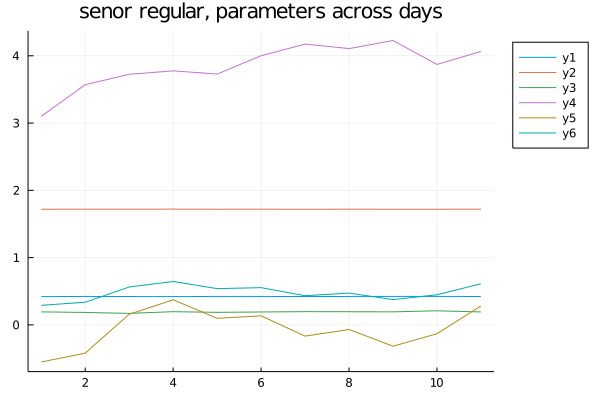

In [21]:
#checking out what happens across days to parameters
using Plots
plot(allparams)
plot!(title=string(rat," regular, parameters across days"),legend = :outertopright)

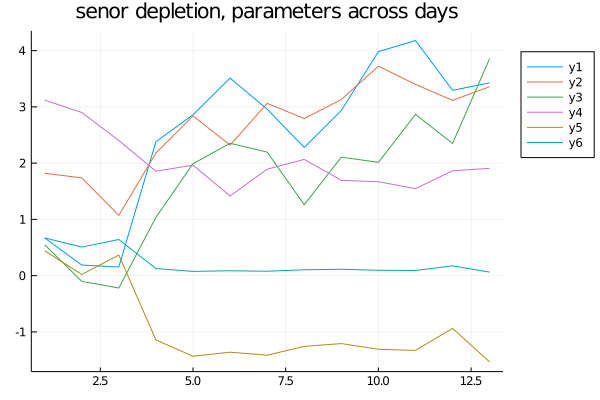

In [19]:
plot(allparams2)
plot!(title=string(rat," depletion, parameters across days"),legend = :outertopright)

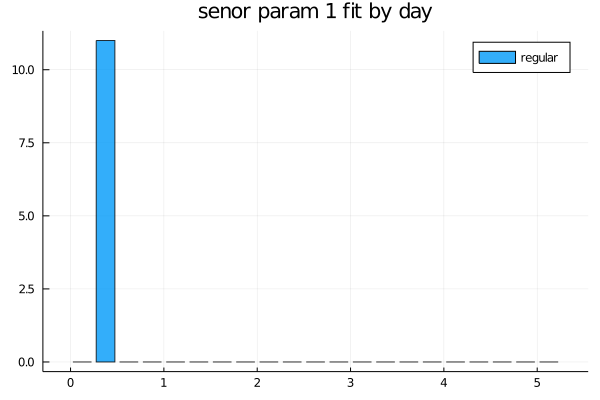

In [23]:
#still just checking out parameters
using Plots
using Distributions

param_ind = 1

paramdata = allparams[:,param_ind]
stepsize=.25
samplespace = 0:stepsize:5

bins = [ count(x->(lb<=x<lb+stepsize),paramdata) for lb in samplespace ]
bar(samplespace.+(stepsize/2),bins,label="regular",alpha=.8)

#=
paramdata = allparams2[:,param_ind]


bins = [ count(x->(lb<=x<lb+stepsize),paramdata) for lb in samplespace ]
bar!(samplespace.+(stepsize/2),bins,label="depletion",alpha=.8)
=# 

bar!(title=string(rat," param ", param_ind," fit by day"))

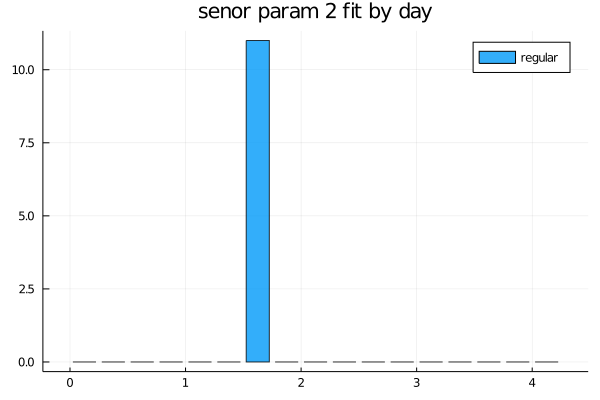

In [24]:
using Plots
using Distributions

param_ind = 2

paramdata = allparams[:,param_ind]
stepsize=.25
samplespace = 0:stepsize:4

bins = [ count(x->(lb<=x<lb+stepsize),paramdata) for lb in samplespace ]
bar(samplespace.+(stepsize/2),bins,label="regular",alpha=.8)

#=
paramdata = allparams2[:,param_ind]

bins = [ count(x->(lb<=x<lb+stepsize),paramdata) for lb in samplespace ]
bar!(samplespace.+(stepsize/2),bins,label="depletion",alpha=.8)
=#

bar!(title=string(rat," param ", param_ind," fit by day"))

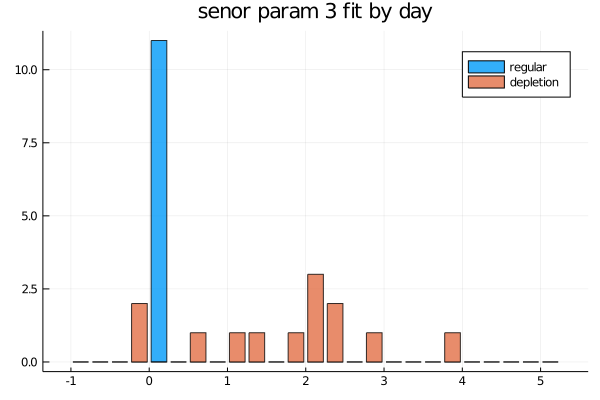

In [51]:
using Plots
using Distributions

param_ind = 3

paramdata = allparams[:,param_ind]
stepsize=.25
samplespace = -1:stepsize:5

bins = [ count(x->(lb<=x<lb+stepsize),paramdata) for lb in samplespace ]
bar(samplespace.+(stepsize/2),bins,label="regular",alpha=.8)

paramdata = allparams2[:,param_ind]

bins = [ count(x->(lb<=x<lb+stepsize),paramdata) for lb in samplespace ]
bar!(samplespace.+(stepsize/2),bins,label="depletion",alpha=.8)
    
bar!(title=string(rat," param ", param_ind," fit by day"))

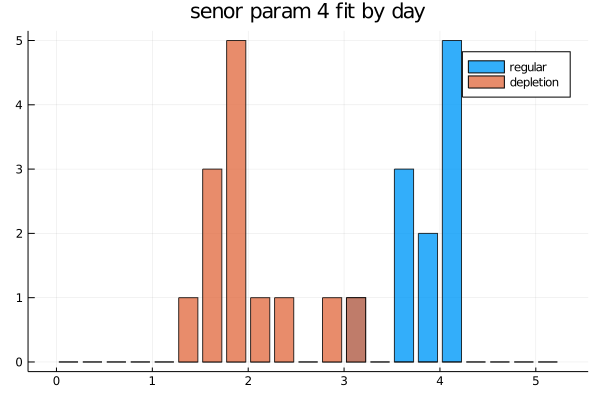

In [56]:
using Plots
using Distributions

param_ind = 4

paramdata = allparams[:,param_ind]
stepsize=.25
samplespace = 0:stepsize:5

bins = [ count(x->(lb<=x<lb+stepsize),paramdata) for lb in samplespace ]
bar(samplespace.+(stepsize/2),bins,label="regular",alpha=.8)

paramdata = allparams2[:,param_ind]

bins = [ count(x->(lb<=x<lb+stepsize),paramdata) for lb in samplespace ]
bar!(samplespace.+(stepsize/2),bins,label="depletion",alpha=.8)
    
bar!(title=string(rat," param ", param_ind," fit by day"))

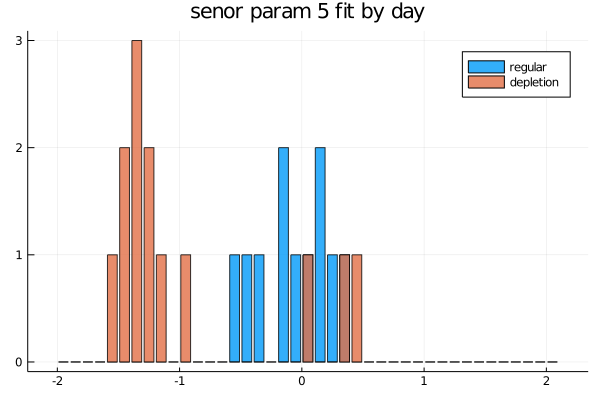

In [59]:
using Plots
using Distributions

param_ind = 5

paramdata = allparams[:,param_ind]
stepsize=.1
samplespace = -2:stepsize:2

bins = [ count(x->(lb<=x<lb+stepsize),paramdata) for lb in samplespace ]
bar(samplespace.+(stepsize/2),bins,label="regular",alpha=.8)

paramdata = allparams2[:,param_ind]

bins = [ count(x->(lb<=x<lb+stepsize),paramdata) for lb in samplespace ]
bar!(samplespace.+(stepsize/2),bins,label="depletion",alpha=.8)
    
bar!(title=string(rat," param ", param_ind," fit by day"))

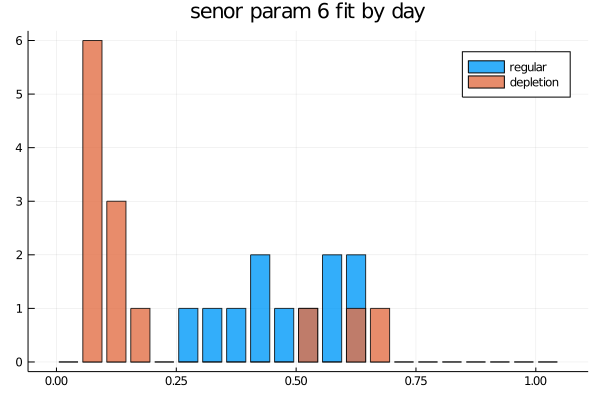

In [61]:
using Plots
using Distributions

param_ind = 6

paramdata = allparams[:,param_ind]
stepsize=.05
samplespace = 0:stepsize:1

bins = [ count(x->(lb<=x<lb+stepsize),paramdata) for lb in samplespace ]
bar(samplespace.+(stepsize/2),bins,label="regular",alpha=.8)

paramdata = allparams2[:,param_ind]

bins = [ count(x->(lb<=x<lb+stepsize),paramdata) for lb in samplespace ]
bar!(samplespace.+(stepsize/2),bins,label="depletion",alpha=.8)
    
bar!(title=string(rat," param ", param_ind," fit by day"))

In [25]:
# now fitting a bunch of nested models (with various regression weights set to 0)
# to test whether behavior is significantly modulated by each piece / see how much variance they capture

# regular task, is stem leave decision dependent on distal stem values?

initbetas = [0. 0 0 0]
initsigma = [5., 5, 5, 1]

(bnogo,snogo,xnogo,lnogo,hnogo) = em(data,subs,X,initbetas,initsigma,qliknogo; emtol=1e-3, parallel=parallel, full=full,maxiter = 1000);


iter: 992
betas: [1.71 0.19 4.05 -0.04]
sigma: [0.0, 0.0, 0.13, 0.11]
free energy: -3873.402672
change: [0.0, 1.0e-6, 0.0, -6.0e-6, 0.001, 0.000219, 0.0, 1.0e-6]
max: 0.001


In [26]:
# now fitting a bunch of nested models (with various regression weights set to 0)
# to test whether behavior is significantly modulated by various value estimates

# depletion task, is stem leave decision dependent on distal stem values?

initbetas = [0. 0 0 0]
initsigma = [5., 5, 5, 1]

(bnogo2,snogo2,xnogo2,lnogo2,hnogo2) = em(data2,subs2,X2,initbetas,initsigma,qliknogo; emtol=1e-3, parallel=parallel, full=full, maxiter = 1000);


iter: 7
betas: [2.31 1.4 2.72 -0.55]
sigma: [0.44, 0.97, 0.09, 0.48]
free energy: -14765.317323
change: [1.9e-5, 3.0e-6, 1.5e-5, -7.0e-6, 9.4e-5, 7.0e-6, 0.000835, 3.1e-5]
max: 0.000835


In [27]:
# regular task, is stem leave decision dependent on current leaf values?

(bnostay,snostay,xnostay,lnostay,hnostay) = em(data,subs,X,initbetas,initsigma,qliknostay; emtol=1e-3, parallel=parallel, full=full,maxiter = 1000);


iter: 1001
betas: [0.38 0.17 3.24 0.05]
sigma: [0.0, 0.01, 0.08, 0.0]
free energy: -4162.859935
change: [6.0e-6, 4.0e-6, 0.0, 0.000117, 0.001032, 4.7e-5, 0.0, 0.001019]
max: 0.001032


In [28]:
# depletion task, is stem leave decision dependent on current leaf values?

(bnostay2,snostay2,xnostay2,lnostay2,hnostay2) = em(data2,subs2,X2,initbetas,initsigma,qliknostay; emtol=1e-3, parallel=parallel, full=full, maxiter = 1500); 


iter: 8
betas: [3.02 1.92 1.06 -1.45]
sigma: [0.91, 1.79, 0.16, 0.04]
free energy: -15437.533994
change: [6.0e-6, 2.9e-5, 2.0e-5, -4.0e-6, 0.000788, 0.000228, 0.00044, 0.000698]
max: 0.000788


In [29]:
# regular task, any sensitivity to leaf values when arriving at new stem?

(bnoleaf,snoleaf,xnoleaf,lnoleaf,hnoleaf) = em(data,subs,X,initbetas,initsigma,qliknoleaf; emtol=1e-3, parallel=parallel, full=full,maxiter = 2000);


iter: 992
betas: [0.42 1.72 3.85 -0.06]
sigma: [0.0, 0.0, 0.11, 0.11]
free energy: -3866.268313
change: [0.0, 0.0, 0.0, -2.0e-6, 0.000987, 0.001, 0.0, 1.0e-6]
max: 0.001


In [30]:
# depletion task, any sensitivity to leaf values when arriving at new stem?

(bnoleaf2,snoleaf2,xnoleaf2,lnoleaf2,hnoleaf2) = em(data2,subs2,X2,initbetas,initsigma,qliknoleaf; emtol=1e-3, parallel=parallel, full=full, maxiter = 1500); 


iter: 7
betas: [2.3 2.57 2.05 -0.85]
sigma: [1.51, 0.53, 0.24, 0.44]
free energy: -14767.328211
change: [9.0e-6, 1.0e-6, 1.9e-5, -6.3e-5, 0.000192, 3.0e-5, 0.000435, 0.000283]
max: 0.000435


In [31]:
# regular task, no value learning at all (just a single parameter coding fixed propensity to switch stems)

initbetas = 0. 
initsigma = [5.]

(bnull,snull,xnull,lnull,hnull) = em(data,subs,X,initbetas,initsigma,qliknull; emtol=1e-3, parallel=parallel, full=full,maxiter = 1000);


iter: 7
betas: 3.43
sigma: [0.09]
free energy: -4172.602756
change: [2.0e-6, 0.000404]
max: 0.000404


In [32]:
# depletion task, no value learning at all (just a single parameter coding fixed propensity to switch stems)

initbetas = 0. 
initsigma = [5.]

(bnull2,snull2,xnull2,lnull2,hnull2) = em(data2,subs2,X2,initbetas,initsigma,qliknull; emtol=1e-3, parallel=parallel, full=full, maxiter = 1500); 


iter: 4
betas: 1.86
sigma: [0.09]
free energy: -16844.619512
change: [1.8e-5, 0.000971]
max: 0.000971


In [33]:
# regular task
# this is one measure of model goodness of fit, aggregated over sessions 
# (can get similar results using session by session cross-validation)
# smaller is better so this shows that each of the coefficients in the model
# is nonzero (ie choices depend on each of these information sources)
display(iaic(x,l,h,b,s))        # this is the full model (best)
display(iaic(xnogo,lnogo,hnogo,bnogo,snogo))   # omitting the value of stems to switch to
display(iaic(xnostay,lnostay,hnostay,bnostay,snostay))   # omitting the value of the current stem
display(iaic(xnoleaf,lnoleaf,hnoleaf,bnoleaf,snoleaf))   # omitting the value of leaves when switching stems (ie choosing leaves randomly)
display(iaic(xnull,lnull,hnull,bnull,snull))   # omitting everything and having only a fixed bias to stay (no value learning null)

3856.57318069187

3863.249437394468

4160.370478901967

3856.7568544755377

4164.099679662209

In [34]:
# depletion task
# this is one measure of model goodness of fit, aggregated over sessions 
# (can get similar results using session by session cross-validation)
# smaller is better so this shows that each of the coefficients in the model
# is nonzero (ie choices depend on each of these information sources)

## thing to note: on this task overall likelihood is much higher (worse fit)
## but this is because the null model explains so much less, which is good (ie the "good fit" in the other case is just predicting "stay")
## the likelihood ratio between the full and null models is much much better than the other task 
## meaning the learning model is doing much much more to explain choices in this version

display(iaic(x2,l2,h2,b2,s2))        # this is the full model (best)
display(iaic(xnogo2,lnogo2,hnogo2,bnogo2,snogo2))   # omitting the value of stems to switch to
display(iaic(xnostay2,lnostay2,hnostay2,bnostay2,snostay2))   # omitting the value of the current stem 
display(iaic(xnoleaf2,lnoleaf2,hnoleaf2,bnoleaf2,snoleaf2))   # omitting the value of leaves when switching stems (ie choosing leaves randomly)
display(iaic(xnull2,lnull2,hnull2,bnull2,snull2))   # omitting everything and having only a fixed bias to stay (no value learning null)

13979.113546087292

14692.689855907229

15373.293909745425

14687.40076857379

16826.170796302406